In [1]:
#### import os
import numpy as np
import pandas as pd
# import nglview as nv
import MDAnalysis as mda # NOTE -- version is 2.4 - not for processing traj (doesn't support nojump)
import MDAnalysis.transformations as tf
from MDAnalysis.analysis import distances
from MDAnalysis.lib import distances as lib_distances
import MDAnalysis.analysis.rms as rms
import pickle
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

import os
import string

/project2/andrewferguson/sivadasetty/doe/ucg/software/mscg/lib/python3.9/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
print(mda.__version__)

2.7.0


In [3]:
# plot settings
showPlots=1
useMagics=1
if useMagics:
    %matplotlib inline
    #%matplotlib notebook
    %load_ext autoreload
    %autoreload 2
    %reload_ext autoreload
    
font = {'weight' : 'normal',
        'size'   : 16}

plt.rc('font', **font)

## Read AA and UCG RDF profiles

In [4]:
# ################################################################################################
# # Read AA RDF [See ../scripts/run_rdf.py  for calculation details]
# ################################################################################################
all_temperatures = [4.5]
    

In [5]:

results_path_runs = {}

for run in range(2,5):

    results_path_size = {}
    
    for size in [1000, 2000, 4000, 8000]:
    
        if size == 0:
            path_to_density = '/project2/andrewferguson/sivadasetty/doe/ucg/notebooks/chiral/manuscript/simulations/rem/high-t-repeat-nneigh12-NR-Hess-7-EXTENDED/validation/'
        else:
            path_to_density = '/project2/andrewferguson/sivadasetty/doe/ucg/notebooks/chiral/manuscript/simulations/rem/high-t-repeat-nneigh12-NR-Hess-7-EXTENDED/size-variation/run'+str(run)+'/size_'+str(size)+'/'
            # path_to_density = '/scratch/midway2/sivadasetty/doe/ucg/chiral/size-variation/run'+str(run)+'/size_'+str(size)+'/'
            
        
        results_path_temperature = {}
        for temperature in all_temperatures:

            results_path_temperature[temperature] = path_to_density + 't_'+str(temperature)+'/'
                    
        results_path_size[size] = results_path_temperature

    results_path_runs[run] = results_path_size



## Read chiral counts

In [6]:
bi_ucg_chiral_count_run = {}

for run in range(2,5):

    bi_ucg_chiral_count_size = {}
    for size in [1000, 2000, 4000, 8000]:
    
        bi_ucg_chiral_count_temperature = {}
        for temperature in all_temperatures:
                        
            ibi_target_folder = results_path_runs[run][size][temperature]
            chiral_results_file_max_6 = ibi_target_folder + '/' + 'count_ld.pkl'
            if os.path.exists(chiral_results_file_max_6):
                with open(chiral_results_file_max_6, 'rb') as file:
                    bi_ucg_chiral_count_temperature[temperature] = pickle.load(file)

            print(size, np.array(list(bi_ucg_chiral_count_temperature[temperature]['l'].keys())).shape)
    
        bi_ucg_chiral_count_size[size] = bi_ucg_chiral_count_temperature

    bi_ucg_chiral_count_run[run] = bi_ucg_chiral_count_size
        
                        

1000 (50001,)
2000 (50001,)
4000 (50001,)
8000 (50001,)
1000 (50001,)
2000 (50001,)
4000 (50001,)
8000 (50001,)
1000 (50001,)
2000 (50001,)
4000 (50001,)
8000 (37988,)


In [8]:
bi_ee_run = {}

for run in range(2,5):
    
    bi_ee_size = {}
    for size in [1000, 2000, 4000, 8000]:
    
        bi_ee_temperature = {}
    
        for temperature in all_temperatures:
            
            start=0
            skip=1
            if size == 8000:
                maxsteps = 37987 #13900
            else:
                maxsteps = -1 
            print(run, size, temperature, np.array(list(bi_ucg_chiral_count_run[run][size][temperature]['l'].values()))[:maxsteps:skip].shape)

            numerator = (np.array(list(bi_ucg_chiral_count_run[run][size][temperature]['l'].values()))[start:maxsteps:skip]-np.array(list(bi_ucg_chiral_count_run[run][size][temperature]['d'].values()))[start:maxsteps:skip])
            denominator = (np.array(list(bi_ucg_chiral_count_run[run][size][temperature]['l'].values()))[start:maxsteps:skip]+np.array(list(bi_ucg_chiral_count_run[run][size][temperature]['d'].values()))[start:maxsteps:skip])
            
            bi_ee_temperature[temperature] = np.array(numerator)/np.array(denominator)

        bi_ee_size[size] = bi_ee_temperature
    
    bi_ee_run[run] = bi_ee_size



2 1000 4.5 (50000,)
2 2000 4.5 (50000,)
2 4000 4.5 (50000,)
2 8000 4.5 (37987,)
3 1000 4.5 (50000,)
3 2000 4.5 (50000,)
3 4000 4.5 (50000,)
3 8000 4.5 (37987,)
4 1000 4.5 (50000,)
4 2000 4.5 (50000,)
4 4000 4.5 (50000,)
4 8000 4.5 (37987,)


In [9]:

full_sample_bi_ee_symmetry_hist_run = {}

for run in range(2,5):

    bi_ee_symmetry_hist_size = {}
    
    for size in [1000, 2000, 4000, 8000]:
        
        bi_ee_symmetry_hist_temperature = {}
        
        for temperature in all_temperatures:
        
            bi_ee_symmetry = np.concatenate((bi_ee_run[run][size][temperature], - bi_ee_run[run][size][temperature]))

            # print(size, bi_ee_run[run][size][temperature].shape, bi_ee_symmetry.shape)

            bi_ee_symmetry_hist, bi_ee_symmetry_bin_edges = np.histogram(bi_ee_symmetry, bins=30, range=[-1,1], density=True)                        

            bi_ee_symmetry_bin_centers = 0.5 * (bi_ee_symmetry_bin_edges[:-1] + bi_ee_symmetry_bin_edges[1:])
            bi_ee_symmetry_hist_temperature[temperature] = {'ee_symmetry_hist': bi_ee_symmetry_hist, 'manual_ee_symmetry_bin_edges': bi_ee_symmetry_bin_edges, 'ee_symmetry_bin_centers': bi_ee_symmetry_bin_centers}

        bi_ee_symmetry_hist_size[size] = bi_ee_symmetry_hist_temperature
                        
    full_sample_bi_ee_symmetry_hist_run[run] = bi_ee_symmetry_hist_size
    

## PLOT

1000 4.5
2000 4.5
4000 4.5
8000 4.5


Text(-0.125, 1.052, '(e)')

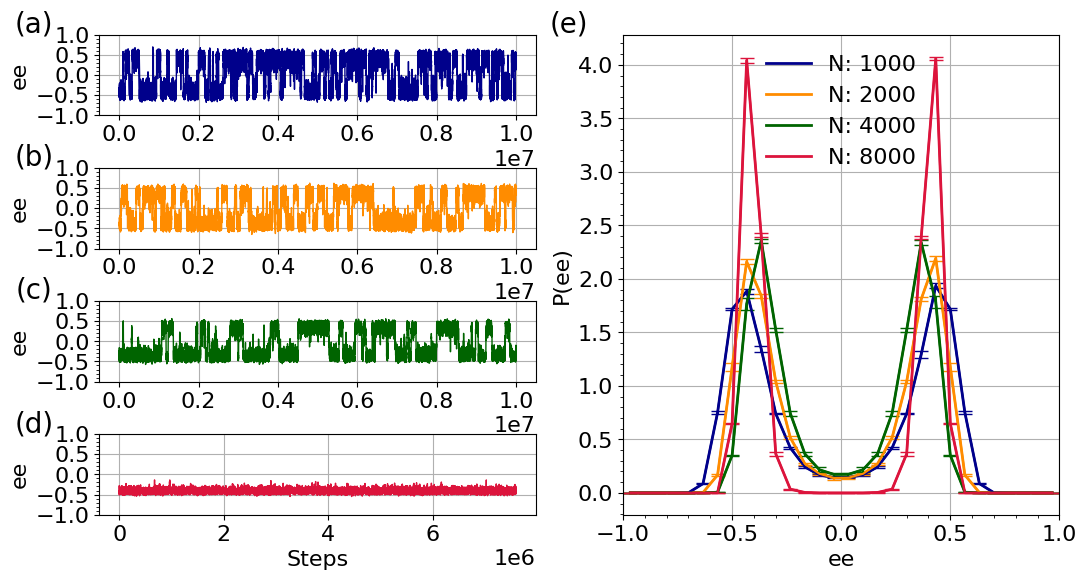

In [10]:

fig = plt.figure(figsize=(12, 6))
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.2, hspace=0.65)
grid = GridSpec(4, 2)

shift_temperature = np.linspace(0, 30., len(all_temperatures))

colors=['darkblue', 'darkorange','darkgreen','crimson']
save_frequency =  200

plot_run = 4
axs = []
for k, size in enumerate([1000, 2000, 4000, 8000]):
    
    for i, temperature in enumerate([all_temperatures[0]]):
    
        print(size, temperature)
        ax1 = plt.subplot(grid[k,0])
        axs.append(ax1)

        for plot_run in [plot_run]:
            ax1.plot(np.arange(bi_ee_run[plot_run][size][temperature][0:].shape[0])*save_frequency,
                     bi_ee_run[plot_run][size][temperature][0:] + shift_temperature[i], 
                     c=colors[k], alpha=1., lw=1)
        
    ax1.set_ylabel("ee")
    ax1.grid()
    #ax1.text(10, 0.65, r'N: ' + str(size), fontsize=12, color=colors[k])
    ax1.set_ylim(-1.,1.)
    # ax2.xaxis.set_major_locator(MultipleLocator(.5))
    ax1.yaxis.set_major_locator(MultipleLocator(.5))
    # ax2.xaxis.set_minor_locator(AutoMinorLocator(n=5))
    ax1.yaxis.set_minor_locator(AutoMinorLocator(n=5))
    
ax1.set_xlabel("Steps")

ax2 = plt.subplot(grid[:4,1])
ax2.grid()
for k, size in enumerate([1000, 2000, 4000, 8000]):
    
    for i, temperature in enumerate([all_temperatures[0]]):
        
        #kt = temperature # 0.008314*temperature
        #print(f'kt: {kt}')
        each_hist = []
        for run in [2,3,4]:
            yval = full_sample_bi_ee_symmetry_hist_run[run][size][temperature]['ee_symmetry_hist']
            each_hist.append(yval)
            
        bfe = np.mean(each_hist, axis=0)
        bfe_err = np.std(each_hist, axis=0, ddof=1)
        ax2.plot(full_sample_bi_ee_symmetry_hist_run[run][size][temperature]['ee_symmetry_bin_centers'], 
                 bfe, c=colors[k], alpha=1., lw=2, label='N: '+str(size))
        ax2.errorbar(full_sample_bi_ee_symmetry_hist_run[run][size][temperature]['ee_symmetry_bin_centers'], bfe, 
                     yerr=bfe_err,c=colors[k], alpha=1., capsize=5)
        
        
ax2.set_ylabel("P(ee)")
# ax2.set_ylabel("FE (kJ/mol)")
ax2.legend(frameon=False)#, loc='upper left')

ax2.set_xlabel("ee")
ax2.set_xlim(-1,1)
ax2.xaxis.set_major_locator(MultipleLocator(.5))
ax2.yaxis.set_major_locator(MultipleLocator(.5))
ax2.yaxis.set_minor_locator(AutoMinorLocator(n=5))
ax2.xaxis.set_minor_locator(AutoMinorLocator(n=5))

    
# #####################################################################################
axs[0].text(-0.15, 1.3, '(' + 'a' + ')', transform=axs[0].transAxes, size=20, weight='normal', va='top', ha='center')
axs[1].text(-0.15, 1.3, '(' + 'b' + ')', transform=axs[1].transAxes, size=20, weight='normal', va='top', ha='center')
axs[2].text(-0.15, 1.3, '(' + 'c' + ')', transform=axs[2].transAxes, size=20, weight='normal', va='top', ha='center')
axs[3].text(-0.15, 1.3, '(' + 'd' + ')', transform=axs[3].transAxes, size=20, weight='normal', va='top', ha='center')

ax2.text(-.125, 1.052, '(' + 'e' + ')', transform=ax2.transAxes, size=20, weight='normal', va='top', ha='center')



### Autocorrelation analysis

In [11]:
from dynamics_analysis import *

In [14]:

ucg_autocorr_runs = {}
for run in [2,3,4]:
    ucg_autocorr_runs_size = {}
    for size in [1000, 2000, 4000, 8000]:
        ucg_autocorr_runs_temperature = {}
        for temperature in bi_ee_run[run][size].keys():
            ee = bi_ee_run[run][size][temperature]
            lags, C = autocorr_ee_direct(ee, max_lag=None)
            
            time = lags * 200 * 0.002 * 50 # 50 is chiral_lag
            
            tau, tau_err, t_fit, C_fit = fit_tau_nonlinear(time, C, fit_until=0.1, lag_max=1e4)
                
            ucg_autocorr_runs_temperature[temperature] = {'lags': lags, 'C': C, 'time': time,
                                                          'tau': tau, 'tau_err': tau_err,
                                                          't_fit': t_fit, 'C_fit': C_fit}

        ucg_autocorr_runs_size[size] = ucg_autocorr_runs_temperature
        
    ucg_autocorr_runs[run] = ucg_autocorr_runs_size
            
        

1000 3667.07225443799 265.27043330667317
2000 5198.021883525757 713.7837261426039
4000 7854.824533203689 1431.6468323640447
8000 570254.5311432964 20707.140153393684


Text(-0.15, 1.05, '(a)')

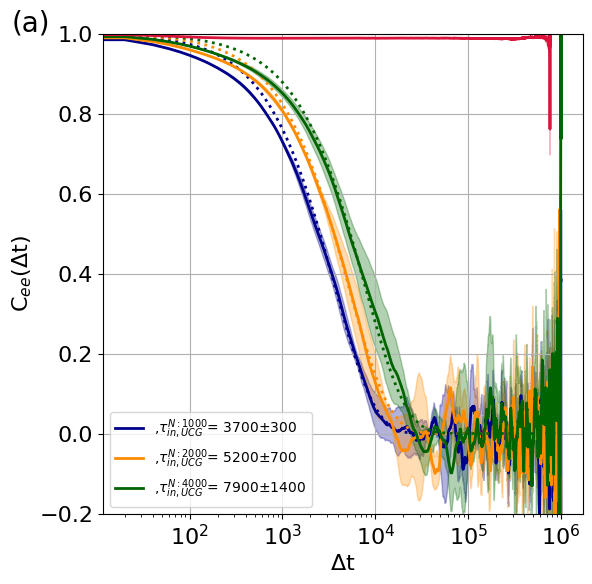

In [15]:
fig = plt.figure(figsize=(6,6))
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.35, hspace=0.4)
grid = GridSpec(1, 1)

ax1 = plt.subplot(grid[0, 0])

ucg_autocorr_mean_size = {}
ucg_autocorr_fit_mean_size = {}
ucg_tau_fit_mean_size = {}

target_temperature = 4.5

for size in [1000, 2000, 4000, 8000]:
    ucg_autocorr_mean = []
    ucg_autocorr_fit_mean = []
    ucg_tau_fit_mean = []
    for run in [2,3,4]:
        ucg_autocorr_mean.append(ucg_autocorr_runs[run][size][target_temperature]['C'])
        ucg_autocorr_fit_mean.append(exp_decay(ucg_autocorr_runs[run][size][target_temperature]['time'], ucg_autocorr_runs[run][size][target_temperature]['tau']))
        ucg_tau_fit_mean.append(ucg_autocorr_runs[run][size][target_temperature]['tau'])

    ucg_autocorr_mean_size[size] = ucg_autocorr_mean
    ucg_autocorr_fit_mean_size[size] = ucg_autocorr_fit_mean
    ucg_tau_fit_mean_size[size] = ucg_tau_fit_mean

# print(ucg_autocorr_mean_size[1000])

ucg_autocorr_fmean = {}
ucg_autocorr_std = {}
ucg_autocorr_fit_fmean = {}
ucg_autocorr_fit_std = {}
ucg_tau_fit_fmean = {}
ucg_tau_fit_std = {}
tau_in_all_sizes_mean = {}
tau_in_all_sizes_std = {}
for size in [1000, 2000, 4000, 8000]:

    # print(size, len(ucg_autocorr_mean_size[size]), ucg_autocorr_mean_size[size][2].shape)
    ucg_autocorr_fmean[size] = np.mean(ucg_autocorr_mean_size[size], axis=0)
    ucg_autocorr_std[size] = np.std(ucg_autocorr_mean_size[size], axis=0, ddof=1)

    ucg_autocorr_fit_fmean[size] = np.mean(ucg_autocorr_fit_mean_size[size], axis=0)
    ucg_autocorr_fit_std[size] = np.std(ucg_autocorr_fit_mean_size[size], axis=0, ddof=1)

    ucg_tau_fit_fmean[size] = np.mean(ucg_tau_fit_mean_size[size], axis=0)
    ucg_tau_fit_std[size] = np.std(ucg_tau_fit_mean_size[size], axis=0, ddof=1)

    tau_in_all_sizes_mean[size] = np.mean(ucg_tau_fit_mean_size[size], axis=0)
    tau_in_all_sizes_std[size] = np.std(ucg_tau_fit_mean_size[size], axis=0, ddof=1)

for size in [1000, 2000, 4000, 8000]:
    print(size, tau_in_all_sizes_mean[size], tau_in_all_sizes_std[size])

colors=['darkblue', 'darkorange','darkgreen','crimson']
for i, size in enumerate([1000, 2000, 4000, 8000]):
    # if size == 8000:
    #     continue

    if size == 8000:
        lab = ''
    else:
        if size == 4000:
            lab = r',$\tau_{in, UCG}^{N: ' + str(size) + '}$= '+str(int(np.round(tau_in_all_sizes_mean[size],-2)))+'$\pm$'+str(int(np.round(tau_in_all_sizes_std[size],-2)))
        else:
            lab = r',$\tau_{in, UCG}^{N: ' + str(size) + '}$= '+str(int(np.round(tau_in_all_sizes_mean[size],-2)))+'$\pm$'+str(int(np.round(tau_in_all_sizes_std[size],-2)))
            
    ax1.plot(ucg_autocorr_runs[run][size][target_temperature]['time'], ucg_autocorr_fmean[size], c=colors[i], lw=2, label=lab)
    ax1.fill_between(ucg_autocorr_runs[run][size][target_temperature]['time'],
                     ucg_autocorr_fmean[size] - ucg_autocorr_std[size],
                     ucg_autocorr_fmean[size] + ucg_autocorr_std[size], color=colors[i], alpha=0.3)
    
    if size != 8000:
        ax1.plot(ucg_autocorr_runs[run][size][target_temperature]['time'], ucg_autocorr_fit_fmean[size], c=colors[i], ls=':', lw=2)
    # ax1.fill_between(ucg_autocorr_runs[run][size][target_temperature]['time'],
    #                  ucg_autocorr_fit_fmean[size] - ucg_autocorr_fit_std[size], 
    #                  ucg_autocorr_fit_fmean[size] + ucg_autocorr_fit_std[size], color=colors[i], alpha=0.3, ls=':')



ax1.set_ylim(-0.2,1)
ax1.set_xscale('log')
ax1.grid()
ax1.legend(frameon=True, fontsize=10)

ax1.set_xlabel(r'$\Delta$t')
ax1.set_ylabel(r'C$_{ee}$($\Delta$t)')

# # ax1.xaxis.set_major_locator(MultipleLocator(1000))
# ax1.yaxis.set_major_locator(MultipleLocator(.25))
# ax1.xaxis.set_minor_locator(AutoMinorLocator(n=5))
# ax1.yaxis.set_minor_locator(AutoMinorLocator(n=5))


##
ax1.text(-0.15, 1.05, '(' + 'a' + ')', transform=ax1.transAxes, size=20, weight='normal', va='top', ha='center')




## Barrier height from characteristic time

In [17]:

delta_in_size_tau_0 = {}
for tau_0 in [50, 100, 1000, 10000]:
    
    delta_in_size = {}
    target_temperature = 4.5
    for size in [1000, 2000, 4000]:
    
        barrier_size = []
        for run in [2, 3, 4]:
            barrier = temperature*np.log(ucg_autocorr_runs[run][size][target_temperature]['tau']/tau_0)
            barrier_size.append(barrier)
            
        delta_in_size[size] = {'mean': np.mean(barrier_size, axis=0), 'std': np.std(barrier_size, axis=0, ddof=1) }

    delta_in_size_tau_0[tau_0] = delta_in_size

for tau_0 in [50, 100, 1000, 10000]:
    for size in [1000, 2000, 4000]:
        print(f'tau_0: {tau_0} size: {size}, mean: {delta_in_size_tau_0[tau_0][size]["mean"]}, std: mean: {delta_in_size_tau_0[tau_0][size]["std"]}')



tau_0: 50 size: 1000, mean: 19.320413720573487, std: mean: 0.3193440002124531
tau_0: 50 size: 2000, mean: 20.86836461176311, std: mean: 0.6404954291849074
tau_0: 50 size: 4000, mean: 22.708047283938413, std: mean: 0.7948824540515093
tau_0: 100 size: 1000, mean: 16.201251408053736, std: mean: 0.31934400021245335
tau_0: 100 size: 2000, mean: 17.749202299243354, std: mean: 0.6404954291849069
tau_0: 100 size: 4000, mean: 19.588884971418665, std: mean: 0.7948824540515078
tau_0: 1000 size: 1000, mean: 5.839618489580528, std: mean: 0.31934400021245246
tau_0: 1000 size: 2000, mean: 7.3875693807701515, std: mean: 0.6404954291849074
tau_0: 1000 size: 4000, mean: 9.227252052945458, std: mean: 0.7948824540515083
tau_0: 10000 size: 1000, mean: -4.5220144288926765, std: mean: 0.3193440002124525
tau_0: 10000 size: 2000, mean: -2.974063537703054, std: mean: 0.6404954291849071
tau_0: 10000 size: 4000, mean: -1.1343808655277476, std: mean: 0.7948824540515079


## |ee| with size

In [18]:

abs_ee_size = {}
temperature = 4.5
for size in [1000, 2000, 4000]:

    abs_ee_run = []
    for run in [2, 3, 4]:
        abs_ee = np.mean(np.abs(bi_ee_run[run][size][temperature]))
        abs_ee_run.append(abs_ee)
    
    abs_ee_size[size] = {'mean': np.mean(abs_ee_run, axis=0), 'std': np.std(abs_ee_run, axis=0, ddof=1) }
    
    print(f'size: {size}, mean: {abs_ee_size[size]["mean"]}, std: mean: {abs_ee_size[size]["std"]}')


size: 1000, mean: 0.40428178666666664, std: mean: 0.0014076789641581289
size: 2000, mean: 0.3732554866666667, std: mean: 0.0023735349679609307
size: 4000, mean: 0.33694128, std: mean: 0.0025381981245954283


A fit:0.022 B fit:17.211


Text(-0.15, 1.05, '(b)')

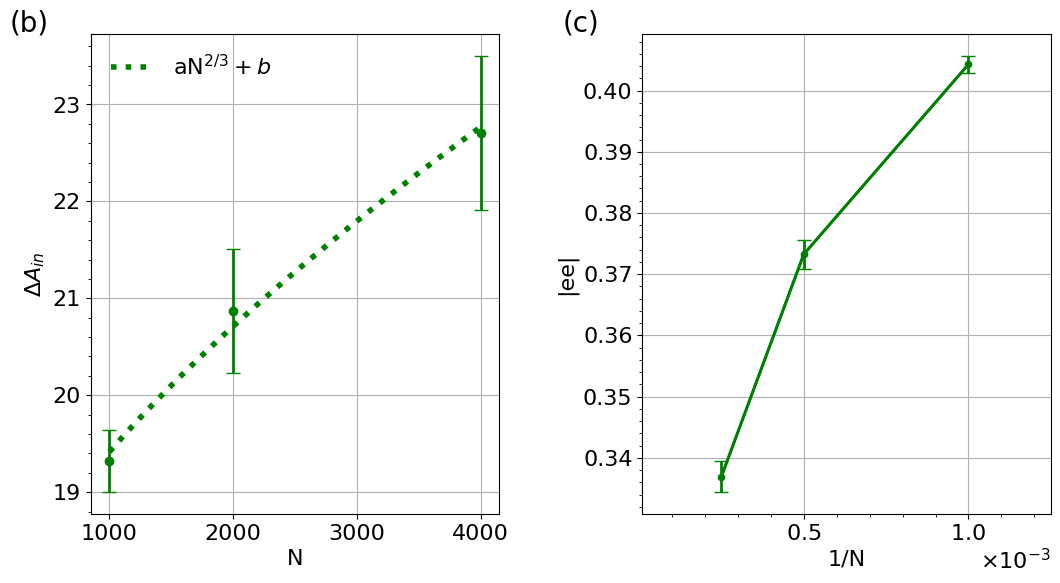

In [19]:
fig = plt.figure(figsize=(12,6))
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.35, hspace=0.4)
grid = GridSpec(1, 2)

##########################################################################################
##########################################################################################
##########################################################################################
######## EE with size

ax1 = plt.subplot(grid[0, 1])

# aa_ee = [0.39, 0.44, 0.46, 0.51]
# x_aa_ee = [4000, 2000, 1000, 500]
# x_aa_ee_inverse = [1/x for x in x_aa_ee]
# ax1.scatter(x_aa_ee_inverse, aa_ee, color='black',s=20)
# ax1.plot(x_aa_ee_inverse, aa_ee, color='black', lw=2, label='AA')

x_ee = []
y_ee = []
y_ee_err = []
for size in [1000, 2000, 4000]:
    
    x_ee.append(1/size)
    y_ee.append(abs_ee_size[size]['mean'])
    y_ee_err.append(abs_ee_size[size]['std'])

ax1.scatter(x_ee, y_ee,color='green',s=20)
ax1.plot(x_ee, y_ee,color='green',lw=2,label='UCG')
ax1.errorbar(x_ee, y_ee, yerr=y_ee_err,color='green',lw=2, elinewidth=2, capsize=5, capthick=1)




# ax1.set_ylim(0.28, 0.6)
# ax1.set_xlim(1*1e-5, 2.5*1e-3)
ax1.set_xlim(1*1e-5, 1.25*1e-3)

ax1.grid()

ax1.set_xlabel('1/N')
ax1.set_ylabel('|ee|')

ax1.ticklabel_format(style='sci', axis='x', scilimits=(0, 0), useMathText=True)
# ax1.legend(frameon=False)

ax1.xaxis.set_major_locator(MultipleLocator(5e-4))
# ax1.yaxis.set_major_locator(MultipleLocator(.25))
ax1.xaxis.set_minor_locator(AutoMinorLocator(n=5))
ax1.yaxis.set_minor_locator(AutoMinorLocator(n=5))

##########################################################################################
##########################################################################################
##########################################################################################
######## Barrier with size
from scipy.optimize import curve_fit

tau_0 = 50 #100
x_barrier = np.array([1000, 2000, 4000])

y_barrier = [delta_in_size_tau_0[tau_0][x]["mean"] for x in x_barrier]
y_barrier_std = [delta_in_size_tau_0[tau_0][x]["std"] for x in x_barrier]

ax2 = plt.subplot(grid[0, 0])

# bar_labels = ['red', 'blue', '_red', 'orange']
bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange']
ax2.scatter(x_barrier, y_barrier, color='green')
ax2.errorbar(x_barrier, y_barrier, yerr=y_barrier_std, color='green',lw=0, elinewidth=2, capsize=5, capthick=1)

def power_law_func(x, A, B):
    return A * (x**(2/3)) + B

popt, pcov = curve_fit(power_law_func, x_barrier, y_barrier)
A_fit, B_fit = popt

x_fit = np.arange(1000, 4000, 10)
y_fit = power_law_func(x_fit, A_fit, B_fit)
print(f'A fit:{np.round(A_fit,3)} B fit:{np.round(B_fit,3)}')

ax2.plot(x_fit, y_fit, ls =':', lw=4, color='green', label=r'aN$^{2/3}+b$')


ax2.set_xlabel('N')
ax2.set_ylabel(r'$\Delta A_{in}$')

ax2.legend(frameon=False)


# ax1.xaxis.set_major_locator(MultipleLocator(5e-4))
ax2.yaxis.set_major_locator(MultipleLocator(1))
# ax1.xaxis.set_minor_locator(AutoMinorLocator(n=5))
ax2.yaxis.set_minor_locator(AutoMinorLocator(n=5))
ax2.grid()


# #####################################################################################
# #####################################################################################
# #####################################################################################
ax1.text(-0.15, 1.05, '(' + 'c' + ')', transform=ax1.transAxes, size=20, weight='normal', va='top', ha='center')
ax2.text(-0.15, 1.05, '(' + 'b' + ')', transform=ax2.transAxes, size=20, weight='normal', va='top', ha='center')



## MFPT as a function of system size

In [20]:

direct_mfpt_runs = {}
temperature = all_temperatures[0]

for run in [2,3,4]:
    direct_mfpt_runs_size = {}
    for size in [1000, 2000, 4000, 8000]:
            
        ee = bi_ee_run[run][size][temperature]
        dt = 200 * 0.002 * 50 # 50 is chiral_lag
        cut = 0.1

        mfpt_AB, passage_times = mfpt_direct_core(ee, dt, L_state = lambda x: x < -cut, D_state = lambda x: x >  cut)
        mfpt_BA, passage_times_BA = mfpt_direct_core(ee, dt, L_state=lambda x: x > cut, D_state=lambda x: x < -cut)

        mfpt_Avg = np.mean(np.concatenate((passage_times, passage_times_BA)))
        mfpt_Std = np.std(np.concatenate((passage_times, passage_times_BA)), ddof=1)
        #print(run, size, mfpt_AB, np.mean(passage_times), mfpt_Avg)
            
        direct_mfpt_runs_size[size] = {'mfpt_AB': mfpt_AB, 'passage_times': passage_times, 
                                       'mfpt_BA': mfpt_BA, 'passage_times_BA': passage_times_BA,
                                       'mfpt_Avg':  mfpt_Avg, 'mfpt_Std': mfpt_Std}
        
    direct_mfpt_runs[run] = direct_mfpt_runs_size


/project2/andrewferguson/sivadasetty/doe/ucg/software/mscg/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/project2/andrewferguson/sivadasetty/doe/ucg/software/mscg/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/project2/andrewferguson/sivadasetty/doe/ucg/software/mscg/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/project2/andrewferguson/sivadasetty/doe/ucg/software/mscg/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/project2/andrewferguson/sivadasetty/doe/ucg/software/mscg/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: inval

Text(0, 0.5, 'MFPT')

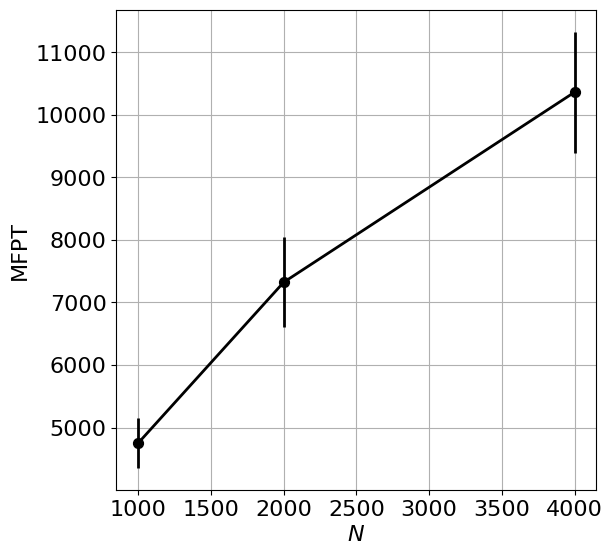

In [21]:
fig = plt.figure(figsize=(6,6))
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.35, hspace=0.4)
grid = GridSpec(1, 1)

ax1 = plt.subplot(grid[0, 0])

##########################################################################################
########## UCG MFPT statistics
##########################################################################################

sizes = [1000, 2000, 4000, 8000]
direct_mfpt_runs_all_sizes_mean = []
direct_mfpt_runs_all_sizes_std = []
direct_mfpt_runs_all_sizes_mean_BA = []
direct_mfpt_runs_all_sizes_std_BA = []
direct_mfpt_runs_all_sizes_mean_Avg = []
direct_mfpt_runs_all_sizes_std_Avg = []


for size in sizes:
    _mfpt_each_run = []
    _mfpt_each_run_BA = []
    _mfpt_each_run_Avg = []
    
    
    for run in [2,3,4]:
        _mfpt_each_run.append(direct_mfpt_runs[run][size]['mfpt_AB'])
        _mfpt_each_run_BA.append(direct_mfpt_runs[run][size]['mfpt_BA'])
        _mfpt_each_run_Avg.append(direct_mfpt_runs[run][size]['mfpt_Avg'])
        
        
    direct_mfpt_runs_all_sizes_mean.append(np.mean(_mfpt_each_run))
    direct_mfpt_runs_all_sizes_std.append(np.std(_mfpt_each_run, ddof=1))
    direct_mfpt_runs_all_sizes_mean_BA.append(np.mean(_mfpt_each_run_BA))
    direct_mfpt_runs_all_sizes_std_BA.append(np.std(_mfpt_each_run_BA, ddof=1))
    direct_mfpt_runs_all_sizes_mean_Avg.append(np.mean(_mfpt_each_run_Avg))
    direct_mfpt_runs_all_sizes_std_Avg.append(np.std(_mfpt_each_run_Avg, ddof=1))
    


##########################################################################################
########## Plot MFPT
##########################################################################################

# ax1.plot(sizes, np.array(tau_in_all_sizes_mean), c='blue', lw=2)
# ax1.errorbar(sizes, tau_in_all_sizes_mean, yerr=tau_in_all_sizes_std, c='blue', lw=2)

# ax1.scatter(1000, np.array(aa_autocorr_temperature[4.5]['tau']), c='blue', s=40)

ax2 = ax1 #.twinx()
# ax2.plot(sizes, direct_mfpt_runs_all_sizes_mean, c='black', lw=2)
# ax2.errorbar(sizes, direct_mfpt_runs_all_sizes_mean, yerr=direct_mfpt_runs_all_sizes_std, c='black', lw=2)

# ax2.plot(sizes, direct_mfpt_runs_all_sizes_mean_BA, c='black', lw=2)
# ax2.errorbar(sizes, direct_mfpt_runs_all_sizes_mean_BA, yerr=direct_mfpt_runs_all_sizes_std_BA, c='green', lw=2)

ax2.scatter(sizes, direct_mfpt_runs_all_sizes_mean_Avg, c='black', s=50)
ax2.errorbar(sizes, direct_mfpt_runs_all_sizes_mean_Avg, yerr=direct_mfpt_runs_all_sizes_std_Avg, c='black', lw=2)

# ax2.scatter(1000, np.array(aa_direct_mfpt[4.5]['aa_mfpt_AB']), c='black', s=40)
# ax2.scatter(1000, np.array(aa_direct_mfpt[4.5]['aa_mfpt_BA']), c='green', s=40)

ax2.grid()

ax1.set_xlabel(r'$N$')
ax1.set_ylabel(r'MFPT')

# # ax1.xaxis.set_major_locator(MultipleLocator(1000))
# ax1.yaxis.set_major_locator(MultipleLocator(.25))
# ax1.xaxis.set_minor_locator(AutoMinorLocator(n=5))
# ax1.yaxis.set_minor_locator(AutoMinorLocator(n=5))



## For table format

In [26]:

for i, size in enumerate([1000, 2000, 4000, 8000]):
    if size == 4000:
        print(f'size: {size}, tau: {np.round(tau_in_all_sizes_mean[size],-2)}, tau_err: {np.round(tau_in_all_sizes_std[size],-2)}, mfpt: {np.round(direct_mfpt_runs_all_sizes_mean_Avg[i],-3)}, mfpt_err: {np.round(direct_mfpt_runs_all_sizes_std_Avg[i],-3)}')
    else:
        print(f'size: {size}, tau: {np.round(tau_in_all_sizes_mean[size],-2)}, tau_err: {np.round(tau_in_all_sizes_std[size],-2)}, mfpt: {np.round(direct_mfpt_runs_all_sizes_mean_Avg[i],-2)}, mfpt_err: {np.round(direct_mfpt_runs_all_sizes_std_Avg[i],-2)}')
    


size: 1000, tau: 3700.0, tau_err: 300.0, mfpt: 4800.0, mfpt_err: 400.0
size: 2000, tau: 5200.0, tau_err: 700.0, mfpt: 7300.0, mfpt_err: 700.0
size: 4000, tau: 7900.0, tau_err: 1400.0, mfpt: 10000.0, mfpt_err: 1000.0
size: 8000, tau: 570300.0, tau_err: 20700.0, mfpt: nan, mfpt_err: nan
